## Text EDA

In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
import re
from pathlib import Path
import sys
sys.path.append("../src")
from data_loader import load_data

In [52]:
data = load_data()

train = data["train"]["listings"].copy()
reviews_train = data["train"]["reviews"].copy()

print("Train listings:", train.shape)
print("Train reviews:", reviews_train.shape)

Train listings: (5928, 41)
Train reviews: (350396, 3)


In [53]:
TEXT_COLUMNS = ["name", "description", "neighborhood_overview", "host_about"]

available_text_cols = [col for col in TEXT_COLUMNS if col in train.columns]
available_text_cols

['name', 'description', 'neighborhood_overview', 'host_about']

In [54]:
missing_text = train[available_text_cols].isna().mean().sort_values(ascending=False) * 100
missing_text

neighborhood_overview    55.448718
host_about               45.107962
description               3.728070
name                      0.000000
dtype: float64

In [55]:
for col in available_text_cols:
    train[f"{col}_length"] = train[col].fillna("").astype(str).str.len()

length_cols = [f"{col}_length" for col in available_text_cols]

train[length_cols].describe()

,name_length,description_length,neighborhood_overview_length,host_about_length
count,5928.000000,5928.000000,5928.000000,5928.000000
mean,36.348516,341.616228,195.082490,171.146592
std,10.821246,145.863398,285.815497,276.551028
min,3.000000,0.000000,0.000000,0.000000
25%,29.000000,247.000000,0.000000,0.000000
50%,36.000000,388.500000,0.000000,28.000000
75%,46.000000,460.000000,338.000000,257.000000
max,250.000000,986.000000,1000.000000,2150.000000


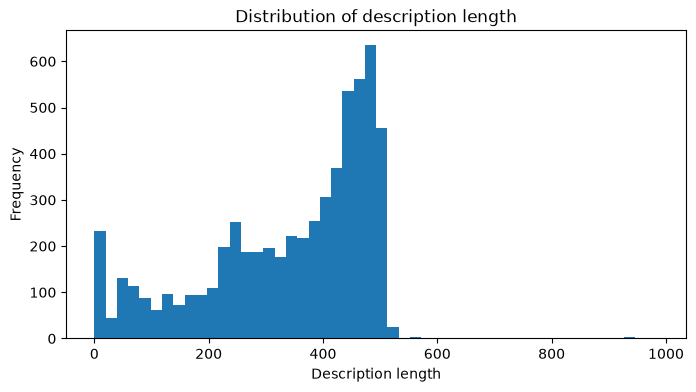

In [56]:
train["description_length"].plot(kind="hist", bins=50, figsize=(8, 4))
plt.xlabel("Description length")
plt.title("Distribution of description length")
plt.show()

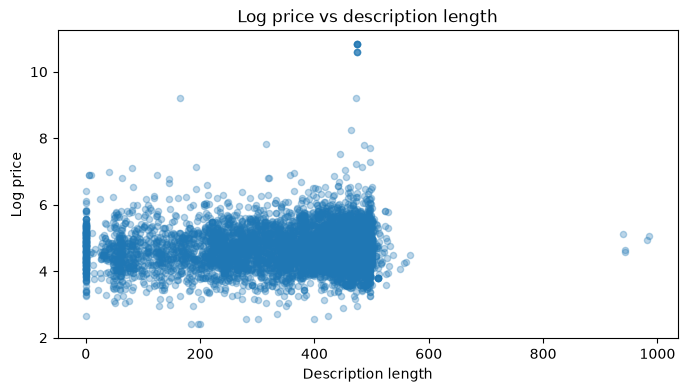

In [57]:
train.plot(
    kind="scatter",
    x="description_length",
    y="log_price",
    alpha=0.3,
    figsize=(8, 4)
)

plt.xlabel("Description length")
plt.ylabel("Log price")
plt.title("Log price vs description length")
plt.show()

In [58]:
def clean_for_words(text):
    text = str(text).lower()
    text = re.sub(r"<[^>]+>", " ", text)
    text = re.sub(r"[^a-zA-ZäöüÄÖÜß]+", " ", text)
    words = text.split()
    return words


STOPWORDS = {
    "the", "and", "for", "with", "this", "that", "you", "your", "are", "our",
    "und", "der", "die", "das", "ein", "eine", "ist", "mit", "für", "auf",
    "in", "im", "of", "to", "a", "an", "is", "it", "as", "at", "by", "from"
}

In [59]:
all_words = []

for text in train["description"].fillna(""):
    words = clean_for_words(text)
    words = [w for w in words if w not in STOPWORDS and len(w) > 2]
    all_words.extend(words)

word_counts = Counter(all_words)
word_counts.most_common(30)

[('apartment', 4989),
 ('berlin', 4160),
 ('room', 3044),
 ('located', 2267),
 ('kitchen', 2117),
 ('living', 1635),
 ('bed', 1590),
 ('equipped', 1538),
 ('quiet', 1468),
 ('bathroom', 1380),
 ('fully', 1337),
 ('city', 1324),
 ('can', 1314),
 ('minutes', 1179),
 ('home', 1121),
 ('has', 1082),
 ('restaurants', 1072),
 ('area', 1071),
 ('bedroom', 1063),
 ('very', 1050),
 ('modern', 1048),
 ('stay', 1046),
 ('all', 995),
 ('cozy', 994),
 ('location', 987),
 ('floor', 970),
 ('spacious', 966),
 ('furnished', 930),
 ('beautiful', 924),
 ('two', 894)]

In [60]:
low_threshold = train["price"].quantile(0.25)
high_threshold = train["price"].quantile(0.75)

cheap = train[train["price"] <= low_threshold]
expensive = train[train["price"] >= high_threshold]

print("Cheap listings:", cheap.shape)
print("Expensive listings:", expensive.shape)

Cheap listings: (1517, 45)
Expensive listings: (1504, 45)


In [61]:
def get_top_words(df, column="description", n=20):
    words_all = []
    for text in df[column].fillna(""):
        words = clean_for_words(text)
        words = [w for w in words if w not in STOPWORDS and len(w) > 2]
        words_all.extend(words)
    return pd.DataFrame(Counter(words_all).most_common(n), columns=["word", "count"])

In [62]:
cheap_words = get_top_words(cheap)
expensive_words = get_top_words(expensive)

cheap_words

,word,count
0,apartment,1121
1,room,1092
2,berlin,998
3,located,592
4,kitchen,534
5,minutes,428
6,quiet,423
7,bed,385
8,bathroom,381
9,very,350


In [63]:
expensive_words

,word,count
0,apartment,1208
1,berlin,1163
2,room,572
3,living,545
4,kitchen,537
5,located,509
6,equipped,440
7,fully,394
8,city,386
9,bed,367


In [64]:
reviews_train.head()

,listing_id,date,comments
150,9991,2015-08-09,The host was very welcoming and hospitable. He...
151,9991,2017-08-06,Nous avons passé une agréable semaine avec nos...
152,9991,2017-08-14,Superb host. Excellent communication and helpf...
153,9991,2017-10-30,Very big clean and well located apartment Phil...
154,9991,2018-07-23,"Very nice flat, very nice area with easy acces..."


In [65]:
print("Number of reviews:", len(reviews_train))
print("Unique listings with reviews:", reviews_train["listing_id"].nunique())

Number of reviews: 350396
Unique listings with reviews: 4609


In [66]:
reviews_per_listing = reviews_train.groupby("listing_id").size()

reviews_per_listing.describe()

count    4609.00000
mean       76.02430
std       134.20261
min         1.00000
25%         7.00000
50%        28.00000
75%        90.00000
max      2895.00000
dtype: float64

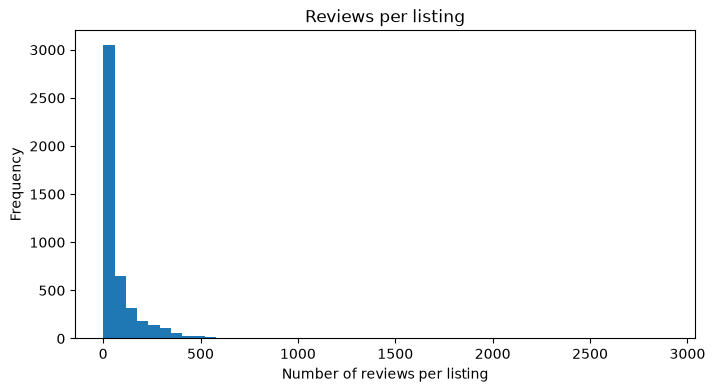

In [67]:
reviews_per_listing.plot(kind="hist", bins=50, figsize=(8, 4))
plt.xlabel("Number of reviews per listing")
plt.title("Reviews per listing")
plt.show()

In [68]:
reviews_train["comment_length"] = reviews_train["comments"].fillna("").astype(str).str.len()

reviews_train["comment_length"].describe()

count    350396.000000
mean        212.071736
std         206.090688
min           1.000000
25%          72.000000
50%         154.000000
75%         285.000000
max        5133.000000
Name: comment_length, dtype: float64

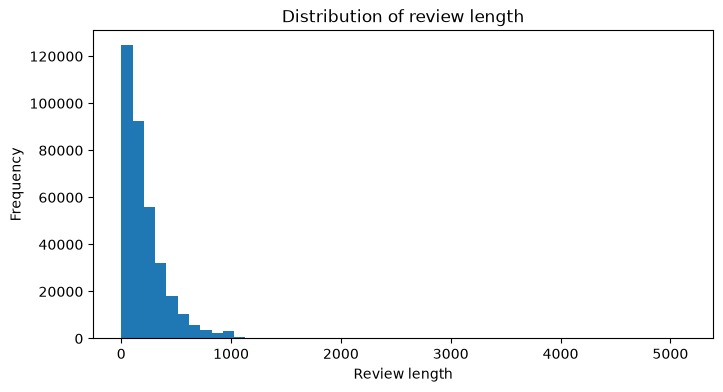

In [69]:
reviews_train["comment_length"].plot(kind="hist", bins=50, figsize=(8, 4))
plt.xlabel("Review length")
plt.title("Distribution of review length")
plt.show()

In [70]:
reviews_train[["listing_id", "comments"]].sample(10, random_state=42)

,listing_id,comments
78068,2883909,Petite chambre mais avec tout le nécessaire po...
180692,13663197,"Simple, comfortable apartment in good location..."
209571,16254081,Very thoughtful people. We landed a bit earlie...
527468,711975137721582244,Erez was one of our favorite AirBnB hosts so f...
464927,48864380,"The appartment is very well located, you can g..."
479477,51097048,The place was as described. Perfectly located ...
500621,54126149,"Fantastic stay. Super clean, lovely rooms, gre..."
575440,995401897371124702,I had the best time staying at R’s place in Be...
494797,53539117,Keine schöne Gegend und es war dreckig
146936,9938743,Trotz meiner so kurzfristigen Buchung klappte ...


In [71]:
tfidf_train_path = Path("../data/processed/text_features_train.csv")

if tfidf_train_path.exists():
    tfidf_train = pd.read_csv(tfidf_train_path)
    print(tfidf_train.shape)
    display(tfidf_train.head())
else:
    print("TF-IDF file not found. Run src/text_features.py first.")

(5928, 501)


,listing_id,tfidf_00,tfidf_10,tfidf_100,tfidf_12,tfidf_15,tfidf_20,tfidf_200,tfidf_24,tfidf_30,...,tfidf_windows,tfidf_wohnung,tfidf_wonderful,tfidf_wooden,tfidf_work,tfidf_working,tfidf_world,tfidf_young,tfidf_zimmer,tfidf_zoo
0,920106836650468460,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0
1,19653235,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0
2,33773317,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.151648,0.0,0.0
3,43549529,0.0,0.0,0.0,0.0,0.0,0.0,0.180868,0.0,0.0,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0
4,1103740828318095406,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,...,0.293822,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0


In [72]:
feature_importance = tfidf_train.drop(columns="listing_id").mean()

feature_importance.sort_values(ascending=False).head(20)

tfidf_located        0.045874
tfidf_city           0.037637
tfidf_quiet          0.037320
tfidf_minutes        0.035196
tfidf_restaurants    0.034227
tfidf_kitchen        0.033261
tfidf_bed            0.030751
tfidf_living         0.030622
tfidf_area           0.030502
tfidf_cozy           0.029438
tfidf_home           0.029128
tfidf_kreuzberg      0.028406
tfidf_beautiful      0.028299
tfidf_mitte          0.027376
tfidf_equipped       0.027340
tfidf_walk           0.026936
tfidf_location       0.026637
tfidf_away           0.026344
tfidf_bathroom       0.026254
tfidf_just           0.026098
dtype: float64

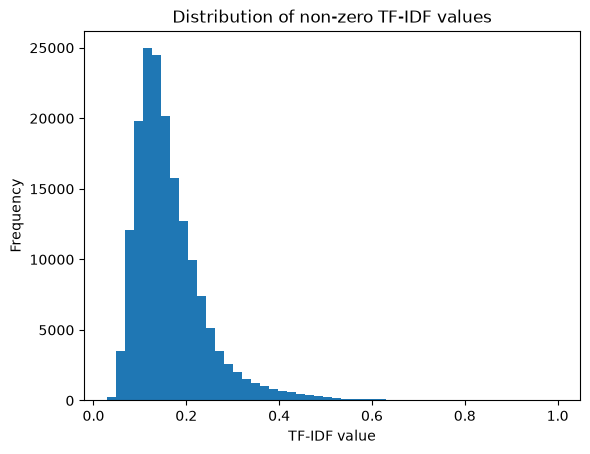

In [73]:
nonzero = tfidf_values[tfidf_values > 0]

plt.hist(nonzero, bins=50)
plt.title("Distribution of non-zero TF-IDF values")
plt.xlabel("TF-IDF value")
plt.ylabel("Frequency")
plt.show()

In [74]:
matrix = tfidf_train.drop(columns="listing_id")

zeros = (matrix == 0).sum().sum()
total = matrix.size

print("Sparsity:", zeros / total)

Sparsity: 0.9416858974358975


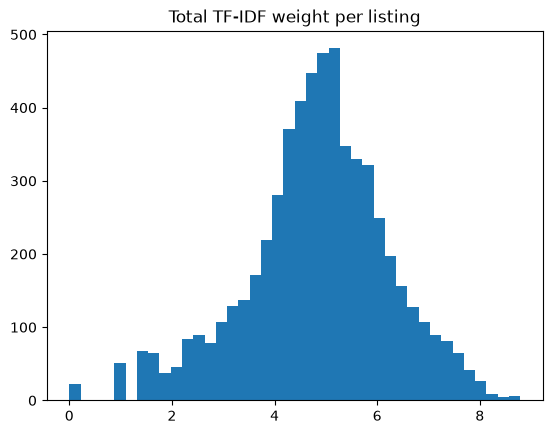

In [75]:
tfidf_sum = matrix.sum(axis=1)

plt.hist(tfidf_sum, bins=40)
plt.title("Total TF-IDF weight per listing")
plt.show()

In [76]:
review_sentiment_train = pd.read_csv("../data/processed/review_sentiment_features_train.csv")

print(review_sentiment_train.shape)
display(review_sentiment_train.head())

review_sentiment_train[
    [
        "review_sentiment_mean",
        "review_sentiment_median",
        "review_sentiment_std",
        "review_count",
        "negative_review_share",
        "positive_review_share",
    ]
].describe()

(4609, 7)


,listing_id,review_sentiment_mean,review_sentiment_median,review_sentiment_std,review_count,negative_review_share,positive_review_share
0,9991,0.796686,0.92010,0.354516,7,0.000000,0.857143
1,22677,0.552347,0.85540,0.545254,600,0.101667,0.748333
2,26543,0.658961,0.91500,0.492882,201,0.074627,0.815920
3,30295,0.573980,0.83160,0.527758,503,0.091451,0.761431
4,37004,0.471511,0.89325,0.702765,38,0.236842,0.736842


,review_sentiment_mean,review_sentiment_median,review_sentiment_std,review_count,negative_review_share,positive_review_share
count,4609.000000,4609.000000,4609.000000,4609.00000,4609.000000,4609.000000
mean,0.336143,0.460184,0.541857,76.02430,0.197571,0.599217
std,0.315897,0.420435,0.219234,134.20261,0.174763,0.230198
min,-0.987700,-0.987700,0.000000,1.00000,0.000000,0.000000
25%,0.168767,0.000000,0.498161,7.00000,0.093923,0.484848
50%,0.354159,0.595050,0.590764,28.00000,0.166667,0.608696
75%,0.528330,0.825500,0.663675,90.00000,0.262712,0.742857
max,0.996250,0.996250,1.370585,2895.00000,1.000000,1.000000


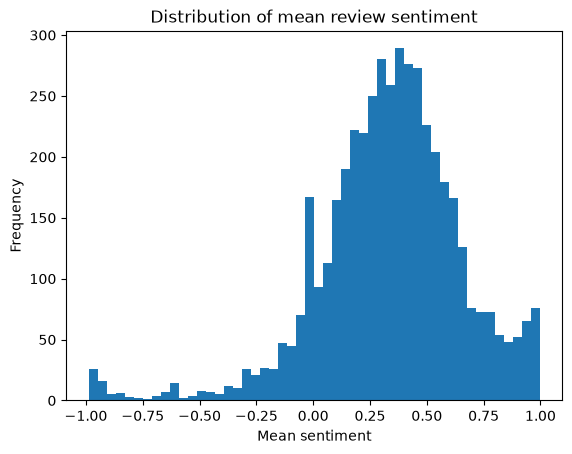

In [77]:
review_sentiment_train["review_sentiment_mean"].plot(kind="hist", bins=50)
plt.title("Distribution of mean review sentiment")
plt.xlabel("Mean sentiment")
plt.show()

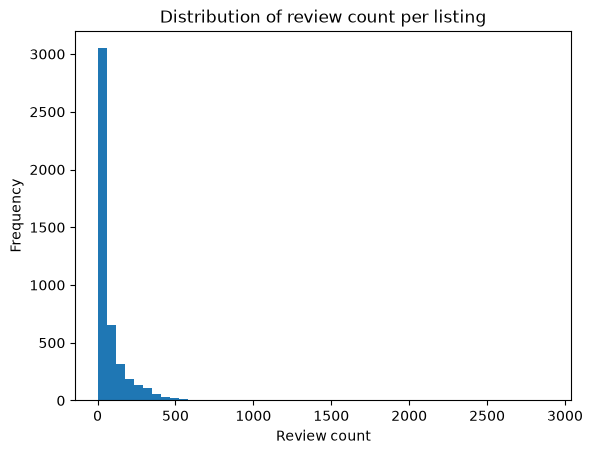

In [78]:
review_sentiment_train["review_count"].plot(kind="hist", bins=50)
plt.title("Distribution of review count per listing")
plt.xlabel("Review count")
plt.show()